# Task-variance clustering

Analysis pipeline from [Yang et al. 2019](https://www.nature.com/articles/s41593-018-0310-2) (Fig. 2):

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import ortho_group
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from task import generate_trials
from train_cog import load_checkpoint, trial_to_tensors

plt.style.use("dark_background")

CHECKPOINT_PATH = "checkpoints/dale_all_tasks.pt"

device=cpu


In [2]:
model, config, checkpoint = load_checkpoint(CHECKPOINT_PATH, device=device, eval_mode=True)
rules = list(checkpoint["active_tasks"])
history = checkpoint.get("history")
n_units = model.n_rnn

print(f"model_type={checkpoint['model_type']}  n_units={n_units}")
print(f"tasks ({len(rules)}): {rules}")
if history is not None:
    print(f"train_steps={checkpoint.get('train_steps')}  final_loss={history['loss'][-1]:.4f}")

DaleRNN: N=128  frac_e=0.8  rho(W)=1.000  activation=relu
Loaded checkpoint <- C:\Users\athar\Documents\Github\canonical_mc\checkpoints\dale_all_tasks.pt  model=dale  tasks=['fdgo', 'reactgo', 'delaygo', 'fdanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'multidm', 'dmsgo']
model_type=dale  n_units=128
tasks (10): ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'multidm', 'dmsgo']
train_steps=7000  final_loss=0.0052


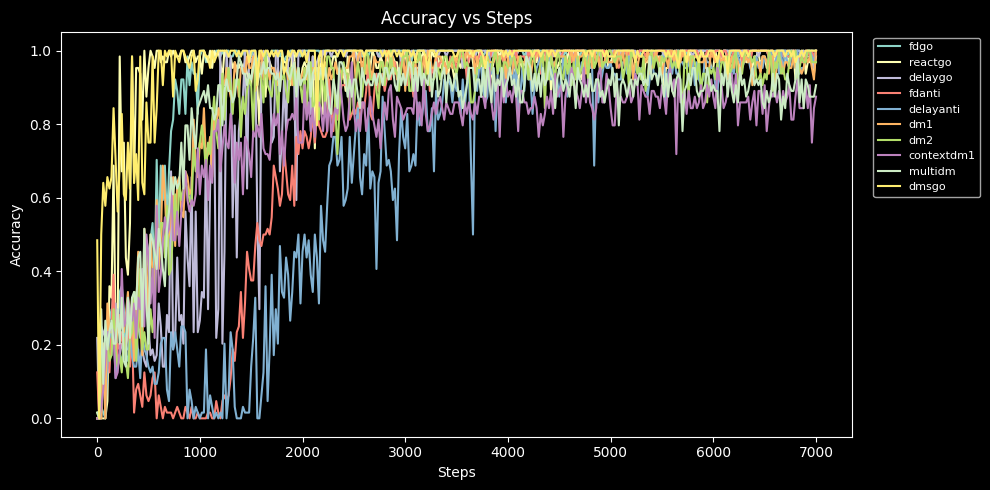

In [3]:
# Training recap: accuracy vs steps
if history is not None and "per_task" in history:
    plt.figure(figsize=(10, 5))
    for task in history["per_task"].keys():
        plt.plot(history["eval_step"], history["per_task"][task]["acc"], label=task)
    plt.xlabel("Steps")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Steps")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No training history in checkpoint.")